<a href="https://colab.research.google.com/github/oszavla/Dirac-Schwarz/blob/main/Confluent_Hypergeometric_Function.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Fungsi $\Gamma$ dan Fungsi *Counfluent Hypergeometric* $F(a,b,z)$

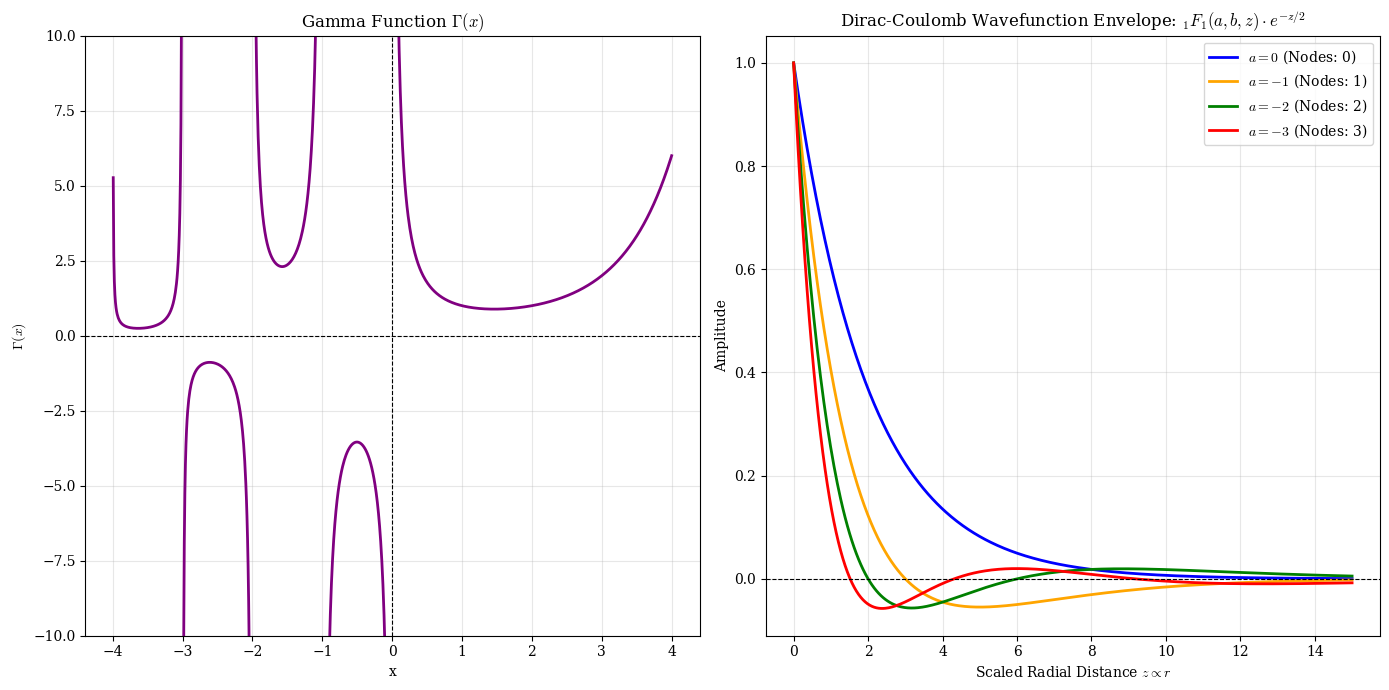

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import hyp1f1, gamma

# Set up the plot style for a scientific look
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'

# ==========================================
# 1. Plotting the Gamma Function
# ==========================================
# The Gamma function diverges at zero and negative integers.
# We will plot it carefully by avoiding exact integer values.
x_gamma = np.linspace(-4, 4, 1000)
# Mask points very close to integers to avoid plotting huge asymptotes
tol = 0.05
y_gamma = gamma(x_gamma)
y_gamma[np.abs(y_gamma) > 20] = np.nan  # Clip the y-axis for cleaner visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].plot(x_gamma, y_gamma, color='purple', lw=2)
axes[0].set_title(r'Gamma Function $\Gamma(x)$')
axes[0].set_xlabel('x')
axes[0].set_ylabel(r'$\Gamma(x)$')
axes[0].axhline(0, color='black', lw=0.8, ls='--')
axes[0].axvline(0, color='black', lw=0.8, ls='--')
axes[0].set_ylim(-10, 10)
axes[0].grid(alpha=0.3)

# ==========================================
# 2. Plotting the Confluent Hypergeometric Function 1F1
# ==========================================
# In the Dirac-Coulomb solution, the argument 'z' is usually proportional to 'r'.
# 'a' depends on the principal quantum number (controlling the nodes).
# 'b' depends on the angular momentum quantum number kappa.

z = np.linspace(0, 15, 500) # Similar to a scaled radial distance rho

# For bound states, 'a' is often zero or a negative integer,
# which turns the hypergeometric series into a finite polynomial (Laguerre polynomial).
# Let's plot a few different 'a' values to see the wave nodes.
b = 3.0  # Constant 'b' for demonstration

a_values = [0, -1, -2, -3] # 0 = Ground state, -1 = 1st excited state, etc.
colors = ['blue', 'orange', 'green', 'red']

for a, color in zip(a_values, colors):
    # hyp1f1 is the scipy function for Kummer's 1F1
    y_hyp = hyp1f1(a, b, z)

    # In QM wavefunctions, 1F1 is multiplied by an exponential decay factor e^(-z/2)
    # This represents the bound state tail.
    wavefunction_envelope = y_hyp * np.exp(-z / 2)

    axes[1].plot(z, wavefunction_envelope, color=color, lw=2,
                 label=rf'$a={a}$ (Nodes: {abs(a)})')

axes[1].set_title(r'Dirac-Coulomb Wavefunction Envelope: $_1F_1(a, {b}, z) \cdot e^{-z/2}$')
axes[1].set_xlabel(r'Scaled Radial Distance $z \propto r$')
axes[1].set_ylabel('Amplitude')
axes[1].axhline(0, color='black', lw=0.8, ls='--')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Fungsi Airy

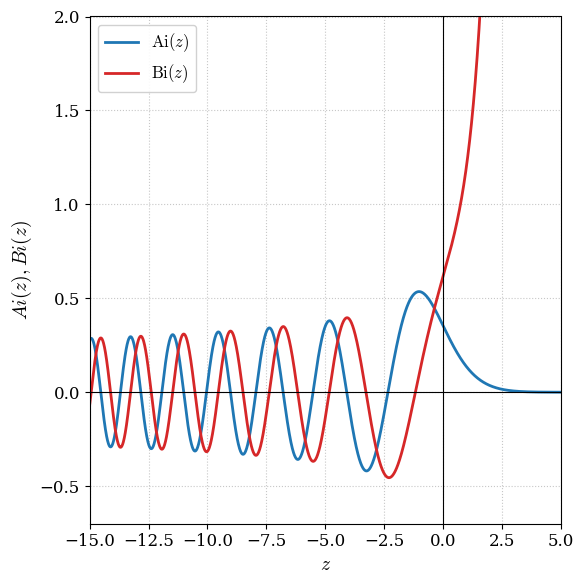

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import airy

# Professional formatting settings for academic papers/theses
plt.rcParams.update({
    "font.family": "serif",      # Serif font matches standard LaTeX body text
    "font.size": 12,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

# Define the range for x
# [-15, 5] is standard to show both the oscillatory and exponential behaviors
x = np.linspace(-15, 5, 2000)

# Calculate Airy functions Ai(x) and Bi(x)
# Note: airy() also returns derivatives Aip and Bip, which we ignore here
Ai, _, Bi, _ = airy(x)

# Create the plot canvas
plt.figure(figsize=(6, 6))

# Plot Ai(x) and Bi(x)
plt.plot(x, Ai, label=r'$\mathrm{Ai}(z)$', color='#1f77b4', linewidth=2)
plt.plot(x, Bi, label=r'$\mathrm{Bi}(z)$', color='#d62728', linewidth=2)

# Add origin axes for reference
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.axvline(0, color='black', linewidth=0.8, linestyle='-')

# Set axis limits
plt.xlim(-15, 5)
# Restrict the y-axis because Bi(x) diverges exponentially for x > 0
plt.ylim(-0.7, 2)

# Add labels, legend, and grid
plt.xlabel(r'$z$')
plt.ylabel(r'$Ai(z),Bi(z)$')
plt.legend(loc='upper left', framealpha=0.9)
plt.grid(True, linestyle=':', alpha=0.7)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Save the figure in high resolution
# 300 dpi is the standard minimum for print/thesis submissions
plt.savefig('airy_functions_thesis.png', dpi=300)
# plt.savefig('airy_functions_thesis.pdf', format='pdf') # Use this for LaTeX